<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Benchmarks</h1>
<h1>GGUF Throughput: HaluEval Prompts</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import datetime
import hashlib
import json
import platform
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import load_dataset
from gguf import GGUFReader
from huggingface_hub import hf_hub_download
from transformers import AutoModelForCausalLM, AutoTokenizer

# vLLM exists only on the Linux install path. The try keeps the first-cell rule intact everywhere.
try:
    import vllm
    from vllm import LLM, SamplingParams
except ImportError:
    vllm = None

import watermark

%load_ext watermark
%matplotlib inline

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 6.17.0-1026-nvidia
Machine     : aarch64
Processor   : aarch64
CPU cores   : 20
Architecture: 64bit

Git hash: f4f1589cdb1d01267b8945b8189ed68a75595728

datasets       : 5.0.0
gguf           : 0.19.0
huggingface_hub: 1.27.0
json           : 2.0.9
matplotlib     : 3.10.8
pandas         : 3.0.3
platform       : 1.0.9
torch          : 2.11.0
transformers   : 5.5.4
vllm           : 0.26.0
watermark      : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Start

One question drives this notebook: how long does a given GGUF take to process N prompts on this machine? It times prompt batches from flowaicom/HaluEval, no correctness scoring, and it sweeps two more axes: repeats of the same prompt and a temperature range. Every generated sample lands in a log with a sequential run id and its temperature, so one benchmark run doubles as a sampling dataset. A visualization section charts throughput scaling, temperature effects, output length, and sample variation.

Device ladder: CUDA runs vLLM. MPS and CPU fall back to transformers, which dequantizes the same GGUF on load. The fallback measures the device, not the quant kernels, so compare engines with that in mind.

Spark note: run this inside the NVIDIA vLLM playbook container. vLLM reads single-file GGUFs for Llama, Qwen, and Gemma architectures. Merge split files first with llama.cpp's `llama-gguf-split --merge`.

## Parameters

The model trio travels together. `GGUF_PATH` wins when the file exists, an empty value triggers a download of `HF_FILE` from `HF_REPO`. `TOKENIZER` points at the base HF repo, which supplies the chat template on every engine.

The sweep runs every temperature against every prompt count. `N_SAMPLES` repeats each prompt within a run. Repeats at temperature 0 would return identical copies, so the code forces one sample there. The CUDA defaults below produce near 10,000 generations in 30 to 40 minutes on the Spark. Add 10000 to `PROMPT_COUNTS` for the full-scale point once the defaults look right.

In [ ]:
GGUF_PATH = ""                                            # local .gguf, empty = download
HF_REPO   = "bartowski/Qwen2.5-7B-Instruct-GGUF"
HF_FILE   = "Qwen2.5-7B-Instruct-Q4_K_M.gguf"
TOKENIZER = "Qwen/Qwen2.5-7B-Instruct"

PROMPT_COUNTS  = None              # None = per-device defaults, or a list like [100, 1000, 10000]
TEMPERATURES   = [1.0] #[0.0, 0.2, 0.4, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]   # the scanned range
N_SAMPLES      = 4                 # repeats per prompt, takes effect above temperature 0
SEED           = 42                 # fixed seed keeps sampled runs reproducible
MAX_NEW        = 96                # tokens generated per prompt
MAX_MODEL_LEN  = 4096
GPU_UTIL       = 0.80              # unified memory on the Spark, leave headroom
FALLBACK_BATCH = 8                 # transformers batch size on mps and cpu
RESULTS_DIR    = "results"

## Pick the device and the engine

In [ ]:
# Why this order: vLLM beats transformers on CUDA by a wide margin, so it wins when present.
# MPS and CPU get transformers, since vLLM ships no kernels for either.
if torch.cuda.is_available() and vllm is not None:
    DEVICE, ENGINE = "cuda", "vllm"
elif torch.cuda.is_available():
    DEVICE, ENGINE = "cuda", "transformers"   # vLLM missing, still usable
elif torch.backends.mps.is_available():
    DEVICE, ENGINE = "mps", "transformers"
else:
    DEVICE, ENGINE = "cpu", "transformers"

# Why per-device defaults: temperatures and repeats multiply the work,
# so the CUDA default stops at 1,000 prompts and the fallback devices stay tiny.
if PROMPT_COUNTS is None:
    PROMPT_COUNTS = {"cuda": [10_000], #[100, 1000],
                     "mps":  [10_000], #[25, 100],
                     "cpu":  [10_000], #[10, 25]
                     }[DEVICE]

n_configs = len(TEMPERATURES) * len(PROMPT_COUNTS)
print(f"device: {DEVICE} | engine: {ENGINE} | counts: {PROMPT_COUNTS} "
      f"| temps: {TEMPERATURES} | samples: {N_SAMPLES} | configs: {n_configs}")

device: cuda | engine: vllm | counts: [100, 1000] | temps: [0.0, 0.4, 0.8] | samples: 4 | configs: 6


## Resolve the model

The fast hash reads the first and last 16 MB plus the file size. That fingerprints a 5 GB file in under a second and stays stable across re-downloads. It keys the leaderboard together with the filename.

In [6]:
def resolve_model():
    if GGUF_PATH and Path(GGUF_PATH).exists():
        return Path(GGUF_PATH)
    print(f"downloading {HF_FILE} from {HF_REPO}")
    return Path(hf_hub_download(repo_id=HF_REPO, filename=HF_FILE))

def fast_hash(path, chunk=16 * 1024 * 1024):
    h = hashlib.sha256()
    size = path.stat().st_size
    with open(path, "rb") as f:
        h.update(f.read(chunk))
        if size > 2 * chunk:
            f.seek(-chunk, 2)
            h.update(f.read(chunk))
    h.update(str(size).encode())
    return h.hexdigest()[:12]

def gguf_meta(path):
    out = {}
    try:
        r = GGUFReader(str(path), "r")
        for key in ("general.name", "general.architecture",
                    "general.size_label", "general.file_type"):
            fld = r.fields.get(key)
            if fld is None:
                continue
            v = fld.parts[fld.data[0]]
            if hasattr(v, "tobytes"):
                try:
                    v = v.tobytes().decode()
                except Exception:
                    v = v.tolist()
            out[key] = v
    except Exception as e:
        out["error"] = str(e)
    return out

model_path = resolve_model()
model_hash = fast_hash(model_path)
meta = gguf_meta(model_path)
size_gb = model_path.stat().st_size / 1e9
print(model_path.name, f"| {size_gb:.2f} GB | hash {model_hash}")
print(meta)

downloading Qwen2.5-7B-Instruct-Q4_K_M.gguf from bartowski/Qwen2.5-7B-Instruct-GGUF
Qwen2.5-7B-Instruct-Q4_K_M.gguf | 4.68 GB | hash 3b3101d52a29
{'general.name': 'Qwen2.5 7B Instruct', 'general.architecture': 'qwen2', 'general.size_label': '7B', 'general.file_type': '\x0f\x00\x00\x00'}


## Load the dataset and build prompts

Rows collapse to unique (passage, question) pairs, which stops repeat prompts from padding the workload by accident. Deliberate repeats come from `N_SAMPLES` instead, and the log tracks them by sample index. The chat template comes from the tokenizer, so every engine sees identical inputs.

In [ ]:
df = load_dataset("flowaicom/HaluEval", split="test").to_pandas()
pairs = df.drop_duplicates(subset=["passage", "question"])[["passage", "question"]]
n_max = min(max(PROMPT_COUNTS), len(pairs))
pairs = pairs.head(n_max)
print(f"rows: {len(df):,} | unique prompts: {len(pairs):,} | using: {n_max:,}")

tok = AutoTokenizer.from_pretrained(TOKENIZER)

INSTRUCTION = ("Answer the question using only the passage. "
               "Give the short answer with no preamble.")

def build(passage, question):
    user = f"{INSTRUCTION}\n\nPassage:\n{passage}\n\nQuestion: {question}"
    return tok.apply_chat_template(
        [{"role": "user", "content": user}],
        tokenize=False, add_generation_prompt=True)

prompt_texts = [build(p, q) for p, q in zip(pairs.passage, pairs.question)]
lens = [len(tok(t).input_ids) for t in prompt_texts]
print(f"prompt tokens | max: {max(lens)} | mean: {sum(lens)//len(lens)} | total: {sum(lens):,}")
assert max(lens) + MAX_NEW <= MAX_MODEL_LEN, "raise MAX_MODEL_LEN"

rows: 10,000 | unique prompts: 1,000 | using: 1,000
prompt tokens | max: 355 | mean: 161 | total: 161,108


## Start the engine

Both branches expose one function: `run(prompts, temperature)` returns prompt tokens, output tokens, and one record per generated sample. The timing loop stays engine-blind.

One accounting note. vLLM shares the prefill across the `n` samples of a prompt, transformers recomputes it per sample. Prompt tokens count once per prompt on both paths, so the workload definition matches, and the speed gap shows up where it belongs: in the clock.

In [8]:
def k_for(temperature):
    # Why clamp: greedy decoding returns identical copies, so repeats add nothing at temperature 0.
    return 1 if temperature == 0 else N_SAMPLES

if ENGINE == "vllm":
    # Why prefix caching off: the sweep reuses nested prompt subsets,
    # and a warm cache would flatter every run after the first.
    llm = LLM(
        model=str(model_path),
        tokenizer=TOKENIZER,
        max_model_len=MAX_MODEL_LEN,
        gpu_memory_utilization=GPU_UTIL,
        enable_prefix_caching=False,
    )

    def run(prompts, temperature):
        k = k_for(temperature)
        # Why a fixed seed: reruns of the same config reproduce the same samples.
        sp = SamplingParams(temperature=temperature, top_p=1.0,
                            max_tokens=MAX_NEW, n=k, seed=SEED)
        outs = llm.generate(prompts, sp)
        p_tok = sum(len(o.prompt_token_ids) for o in outs)
        o_tok, gens = 0, []
        for pi, o in enumerate(outs):
            for si, seq in enumerate(o.outputs):
                o_tok += len(seq.token_ids)
                gens.append((pi, si, len(seq.token_ids), seq.text.strip()))
        return p_tok, o_tok, gens

    engine_version = vllm.__version__

else:
    # Why float16 off cpu: mps runs half precision well, cpu wants float32.
    dt = torch.float32 if DEVICE == "cpu" else torch.float16
    # transformers dequantizes the GGUF on load, so memory equals params times dtype size.
    model = AutoModelForCausalLM.from_pretrained(
        str(model_path.parent), gguf_file=model_path.name, torch_dtype=dt
    ).to(DEVICE).eval()

    # Why left padding: decoder-only generation appends on the right,
    # so padding must sit on the left to keep every row aligned.
    tok.padding_side = "left"
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    def run(prompts, temperature):
        k = k_for(temperature)
        torch.manual_seed(SEED)
        kwargs = dict(max_new_tokens=MAX_NEW, num_return_sequences=k,
                      pad_token_id=tok.pad_token_id)
        if temperature > 0:
            kwargs.update(do_sample=True, temperature=temperature, top_p=1.0)
        else:
            kwargs.update(do_sample=False)

        p_tok, o_tok, gens = 0, 0, []
        for i in range(0, len(prompts), FALLBACK_BATCH):
            batch = prompts[i:i + FALLBACK_BATCH]
            enc = tok(batch, return_tensors="pt", padding=True).to(DEVICE)
            with torch.no_grad():
                out = model.generate(**enc, **kwargs)
            p_tok += int(enc.attention_mask.sum())
            gen = out[:, enc.input_ids.shape[1]:]
            for j in range(gen.shape[0]):
                pi, si = i + j // k, j % k
                row = gen[j]
                # Pad tokens after eos drop out of the count. Close enough for throughput.
                n_t = int((row != tok.pad_token_id).sum())
                o_tok += n_t
                gens.append((pi, si, n_t, tok.decode(row, skip_special_tokens=True).strip()))
        return p_tok, o_tok, gens

    engine_version = transformers.__version__

print(f"{ENGINE} {engine_version} ready on {DEVICE}")

INFO 08-16 16:55:40 [__init__.py:112] Registered model loader `<class 'vllm_gguf_plugin.loader.GGUFModelLoader'>` with load format `gguf`
INFO 08-16 16:55:40 [config.py:455] Registered config parser `<class 'vllm_gguf_plugin.config_parser.GGUFConfigParser'>` with config format `gguf`
INFO 08-16 16:55:40 [api_utils.py:273] non-default args: {'tokenizer': 'Qwen/Qwen2.5-7B-Instruct', 'max_model_len': 4096, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.7, 'disable_log_stats': True, 'model': '/home/bgoncalves/.cache/huggingface/hub/models--bartowski--Qwen2.5-7B-Instruct-GGUF/snapshots/8911e8a47f92bac19d6f5c64a2e2095bd2f7d031/Qwen2.5-7B-Instruct-Q4_K_M.gguf'}
INFO 08-16 16:55:41 [model.py:623] Resolved architecture: Qwen2ForCausalLM
INFO 08-16 16:55:41 [model.py:1788] Using max model len 4096
INFO 08-16 16:55:41 [scheduler.py:252] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 08-16 16:55:41 [vllm.py:1109] Asynchronous scheduling is enabled.
INFO 08-16 16:55:

(EngineCore pid=890992) 2026-08-16 16:56:31,686 - INFO - autotuner.py:651 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore pid=890992) 2026-08-16 16:56:51,156 - INFO - autotuner.py:674 - flashinfer.jit: [Autotuner]: Autotuning process ends


(EngineCore pid=890992) WARNING 08-16 16:56:51 [kernel_warmup.py:258] No FlashInfer autotune cache entries found.Falling back to default tactics.
(EngineCore pid=890992) INFO 08-16 16:56:51 [kernel_warmup.py:65] Warming up ll_bf16 router GEMM kernels.
(EngineCore pid=890992) INFO 08-16 16:56:55 [cutedsl_warmup.py:101] Skipping CuTeDSL warmup because no compile units were requested.


Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:49<00:00,  1.41s/it]


(EngineCore pid=890992) INFO 08-16 16:57:57 [model_runner.py:747] Graph capturing finished in 61 secs, took 0.27 GiB
(EngineCore pid=890992) INFO 08-16 16:57:57 [gpu_worker.py:857] Free memory on device (111.7/121.69 GiB) on startup. Desired GPU memory utilization is (0.7, 85.18 GiB). Actual usage is 7.03 GiB for weight, 1.03 GiB for peak activation, 2.69 GiB for non-torch memory, and 0.27 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=79477363303` (74.02 GiB) to fit into requested memory, or `--kv-cache-memory=107946660864` (100.53 GiB) to fully utilize gpu memory. Current kv cache memory in use is 74.43 GiB.
(EngineCore pid=890992) INFO 08-16 16:58:37 [jit_monitor.py:79] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=890992) INFO 08-16 16:58:38 [core.py:340] init engine (profile, create kv cache, warmup model) took 155.03 s (compilation: 13.74 s)
(EngineCore pid=890992) INFO 08-16 

## Warm up, then sweep

The warmup pass absorbs one-time costs: graph capture, allocator growth, and kernel compilation. Timed runs then measure steady state only. The sweep walks every temperature against every prompt count. Each generated sample gets the next sequential `run_id`, its temperature, its prompt index, and its sample index.

In [9]:
run(prompt_texts[:min(8, len(prompt_texts))], TEMPERATURES[0])   # warmup, untimed

run_counter = 0
gen_log = []
rows = []
for temp in TEMPERATURES:
    for n in PROMPT_COUNTS:
        n = min(n, len(prompt_texts))
        t0 = time.time()
        p_tok, o_tok, gens = run(prompt_texts[:n], temp)
        wall = time.time() - t0
        for pi, si, n_t, text in gens:
            gen_log.append({"run_id": run_counter, "temperature": temp,
                            "n_prompts": n, "prompt_idx": pi, "sample_idx": si,
                            "out_tokens": n_t, "text": text})
            run_counter += 1
        rows.append({
            "temperature": temp,
            "n_prompts": n,
            "n_samples": k_for(temp),
            "n_generations": len(gens),
            "wall_s": round(wall, 1),
            "prompt_tokens": p_tok,
            "output_tokens": o_tok,
            "prompt_tok_s": round(p_tok / wall),
            "output_tok_s": round(o_tok / wall),
            "prompts_per_s": round(n / wall, 2),
        })
        print(f"T={temp:.1f} | n={n:>6,} x{k_for(temp)} | {wall:7.1f} s "
              f"| prompt {p_tok/wall:8,.0f} tok/s | output {o_tok/wall:7,.0f} tok/s")

bench = pd.DataFrame(rows)
gen_df = pd.DataFrame(gen_log)
print(f"\ngenerations logged: {run_counter:,}")
bench

Rendering prompts:   0%|          | 0/8 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 8/8 [00:01<00:00,  6.82it/s, est. speed input: 1099.18 toks/s, output: 22.19 toks/s]


Rendering prompts:   0%|          | 0/100 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 100/100 [00:14<00:00,  6.78it/s, est. speed input: 1101.28 toks/s, output: 30.46 toks/s]

T=0.0 | n=   100 x1 |    14.8 s | prompt    1,098 tok/s | output      30 tok/s


...

T=0.8 | n=   100 x4 |    56.2 s | prompt      289 tok/s | output      33 tok/s


Rendering prompts:   0%|          | 0/1000 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 4000/4000 [09:08<00:00,  7.29it/s, est. speed input: 1175.17 toks/s, output: 36.70 toks/s]


T=0.8 | n= 1,000 x4 |   548.8 s | prompt      294 tok/s | output      37 tok/s

generations logged: 9,900


,temperature,n_prompts,n_samples,n_generations,wall_s,prompt_tokens,output_tokens,prompt_tok_s,output_tok_s,prompts_per_s
0,0.0,100,1,100,14.8,16236,449,1098,30,6.76
1,0.0,1000,1,1000,322.1,161108,4951,500,15,3.11
2,0.4,100,4,400,122.4,16236,1824,133,15,0.82
3,0.4,1000,4,4000,553.7,161108,20030,291,36,1.81
4,0.8,100,4,400,56.2,16236,1838,289,33,1.78
5,0.8,1000,4,4000,548.8,161108,20124,294,37,1.82


## Visualize the sweep

Four views. Throughput scaling shows the engine, the temperature panels show the sampling cost, the length distributions show the mechanism, and the repeat-variation panel shows what temperature buys in output diversity.

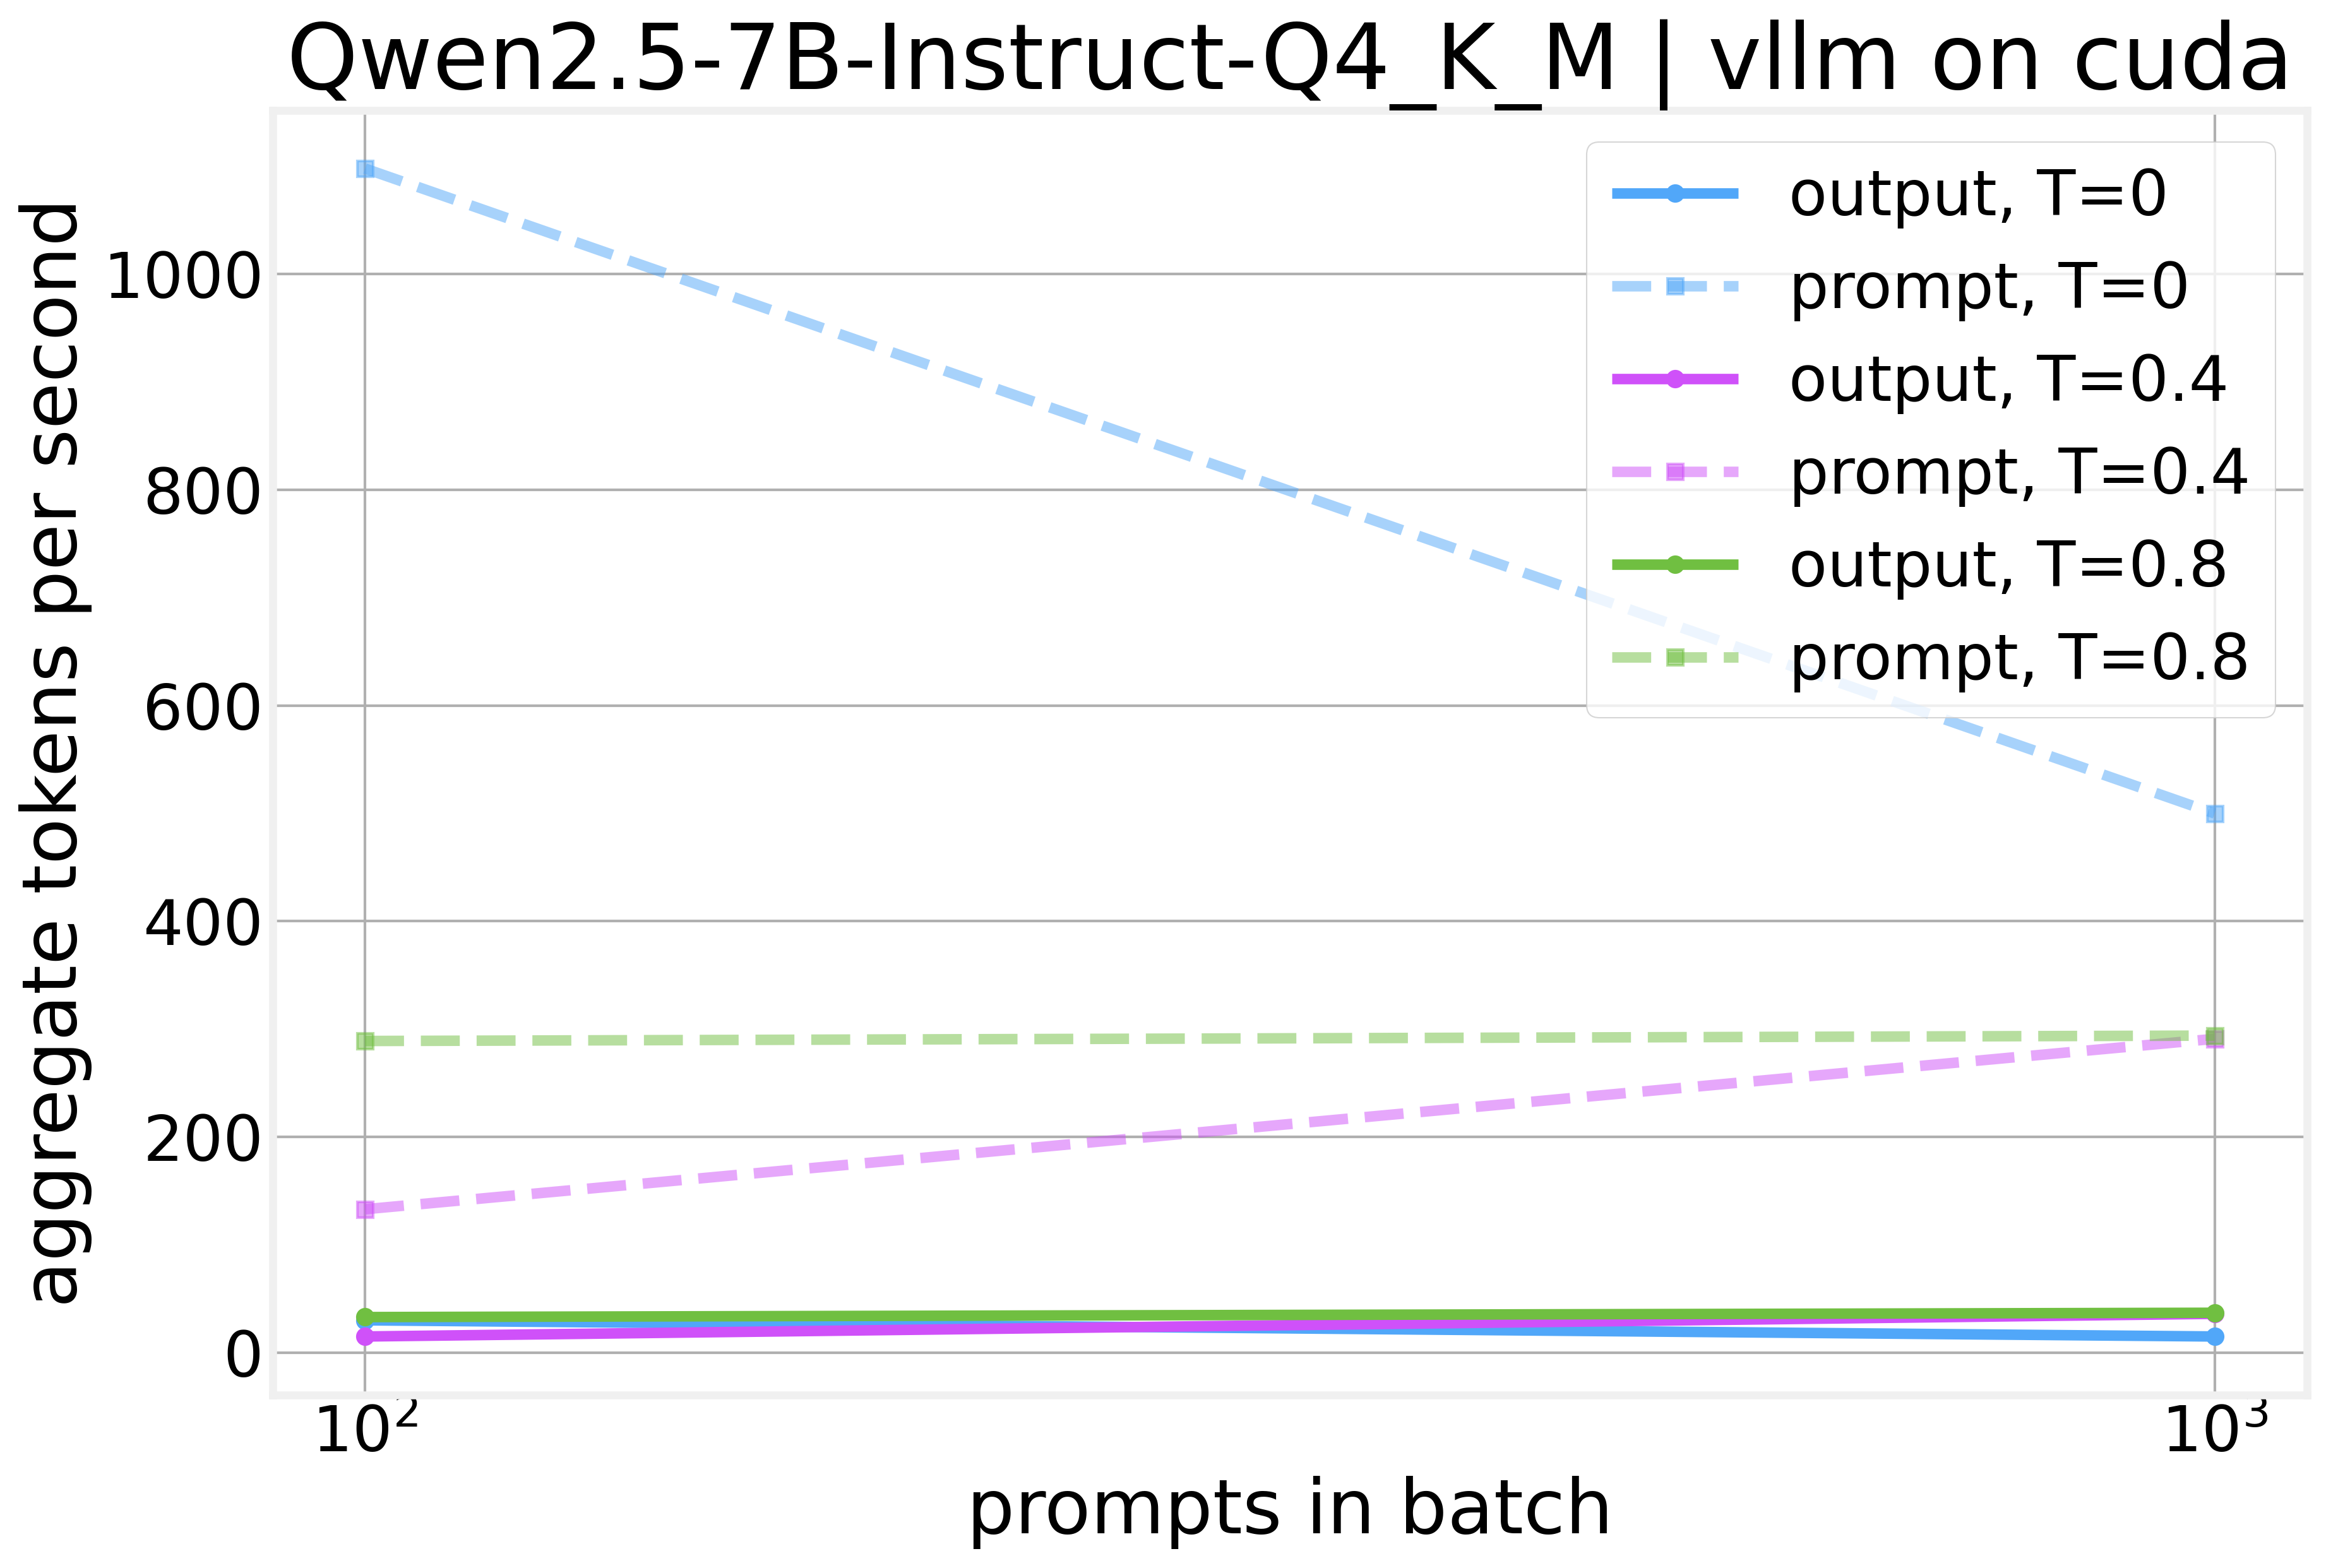

In [10]:
# Why one line per temperature: scaling and sampling cost land on the same axes.
fig, ax = plt.subplots()
for ci, (temp, grp) in enumerate(bench.groupby("temperature")):
    c = colors[ci % len(colors)]
    ax.plot(grp.n_prompts, grp.output_tok_s, "o-", color=c, label=f"output, T={temp:g}")
    ax.plot(grp.n_prompts, grp.prompt_tok_s, "s--", color=c, alpha=0.5, label=f"prompt, T={temp:g}")
ax.set_xscale("log")
ax.set_xlabel("prompts in batch")
ax.set_ylabel("aggregate tokens per second")
ax.set_title(f"{model_path.stem} | {ENGINE} on {DEVICE}")
ax.legend()
plt.tight_layout()
plt.show()

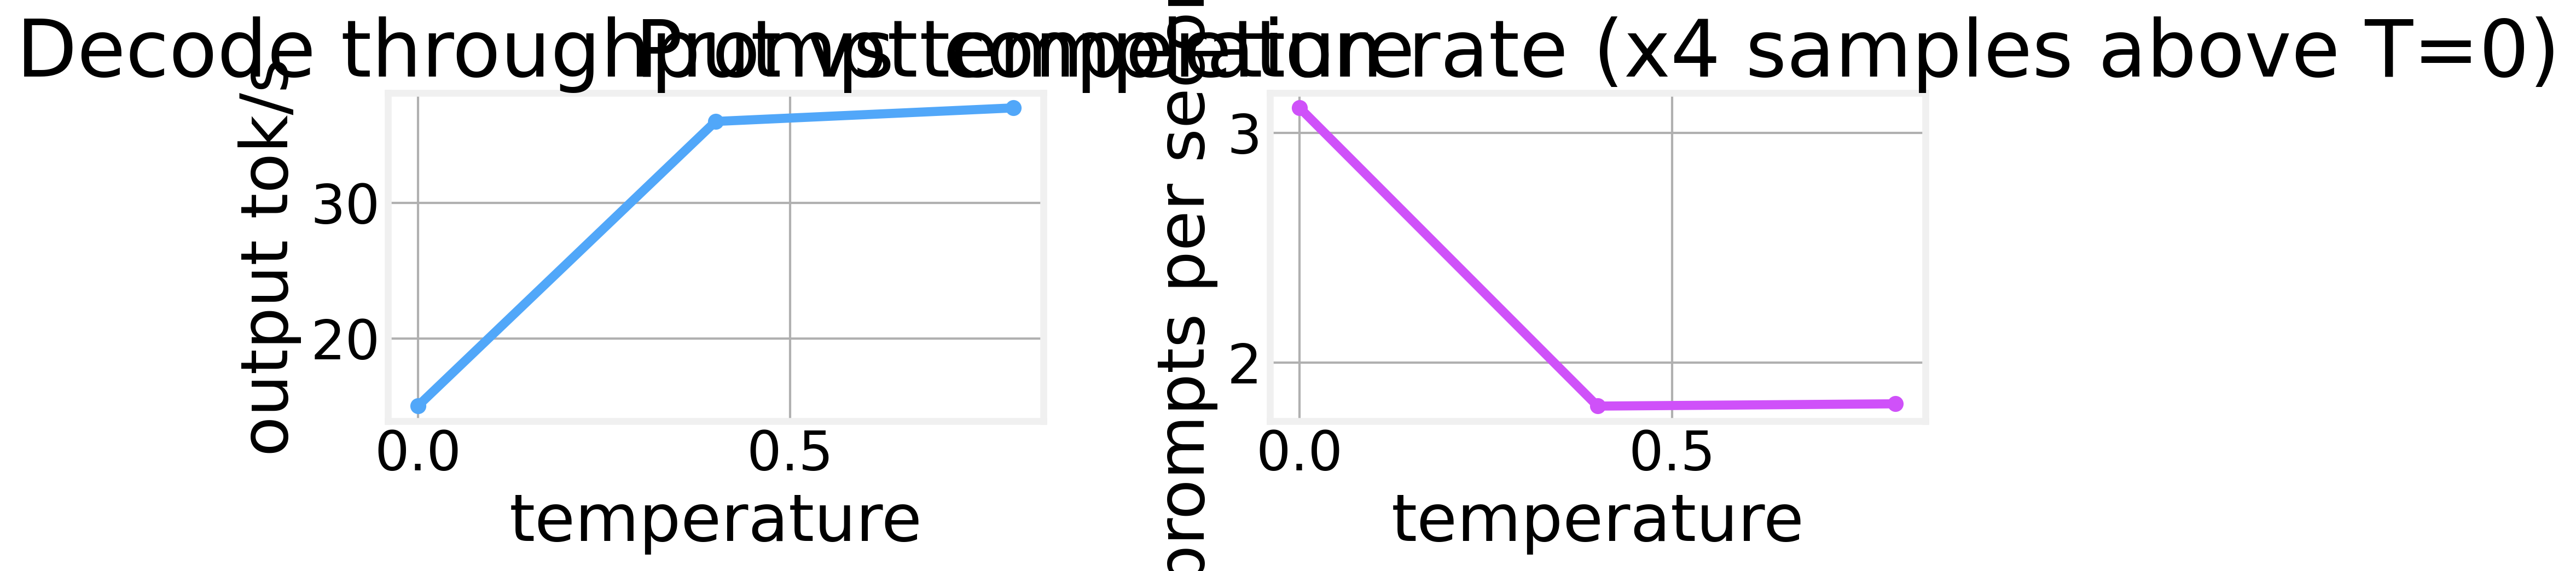

In [11]:
# Why the largest batch: steady state lives there, small batches measure startup overhead.
big = bench[bench.n_prompts == bench.n_prompts.max()].sort_values("temperature")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(big.temperature, big.output_tok_s, "o-", color=colors[0])
axes[0].set_xlabel("temperature")
axes[0].set_ylabel("output tok/s")
axes[0].set_title("Decode throughput vs temperature")

# Why prompts/s here: repeats multiply decode work per prompt, and this axis shows the bill.
axes[1].plot(big.temperature, big.prompts_per_s, "o-", color=colors[1])
axes[1].set_xlabel("temperature")
axes[1].set_ylabel("prompts per second")
axes[1].set_title(f"Prompt completion rate (x{N_SAMPLES} samples above T=0)")
plt.tight_layout()
plt.show()

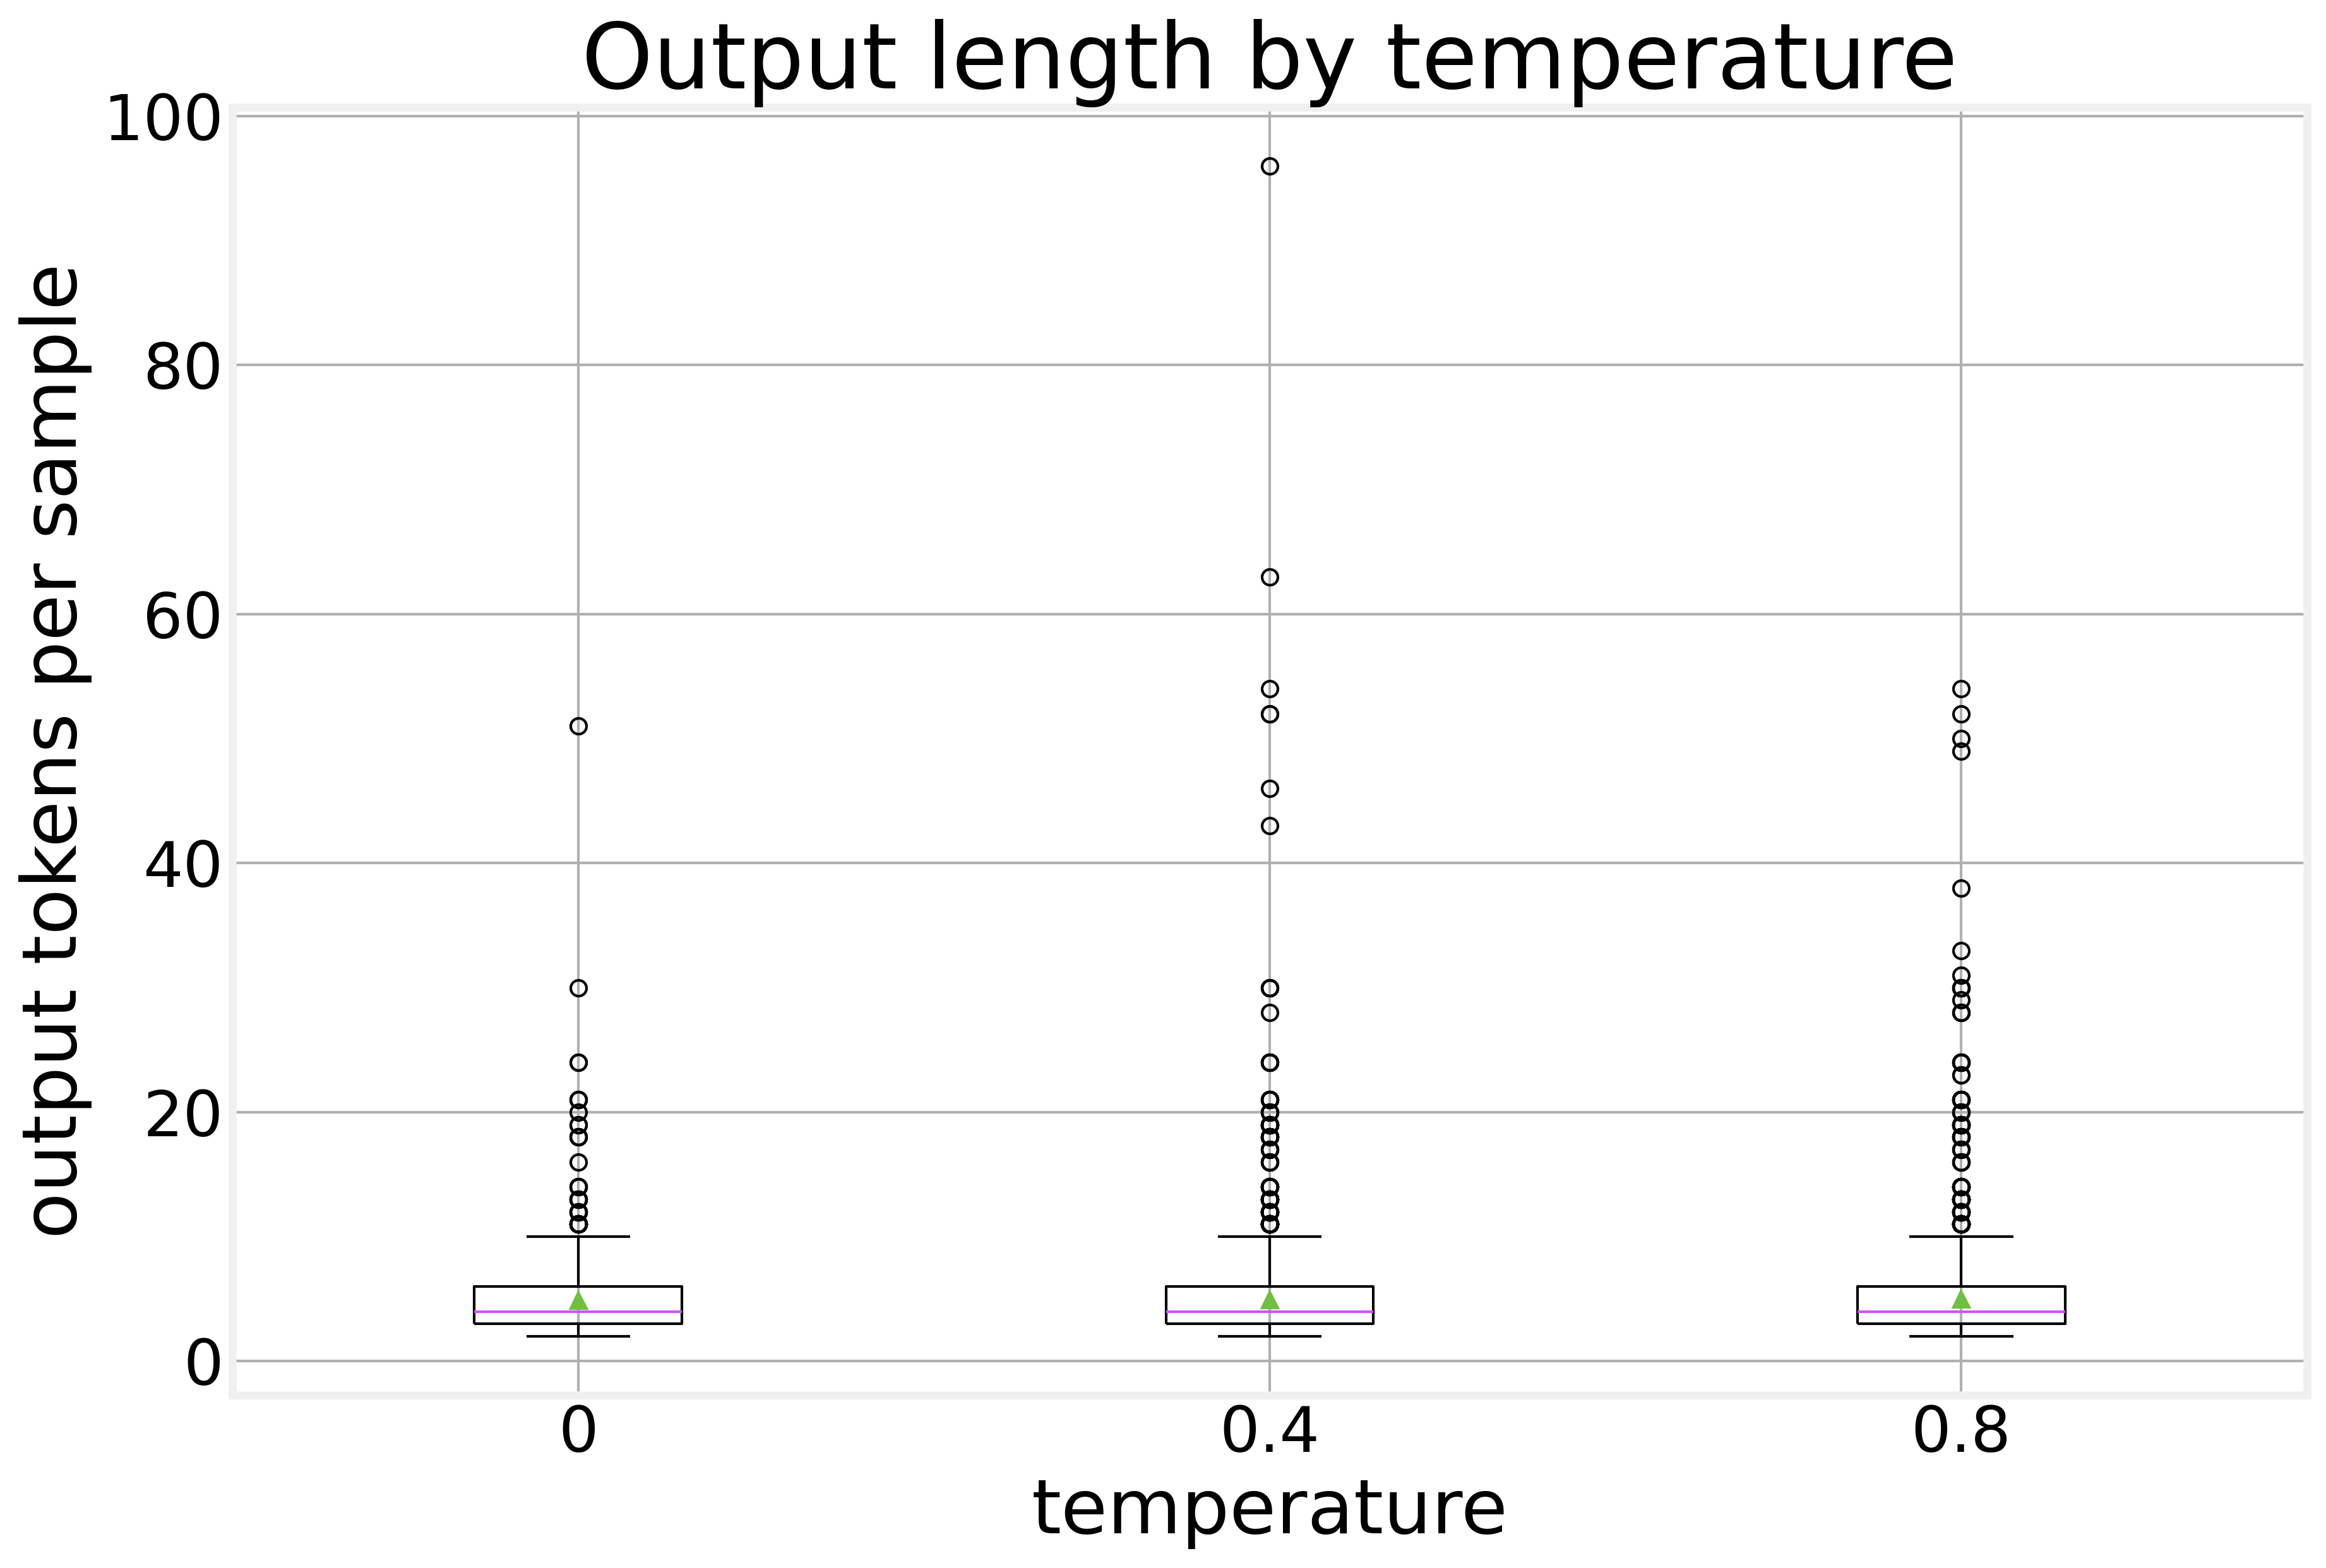

,mean,median,std,max
temperature,,,,
0.0,4.9,4.0,3.1,51
0.4,5.0,4.0,3.6,96
0.8,5.0,4.0,3.4,54


In [12]:
# Why length distributions: temperature moves output length, and length moves every tok/s number.
temps = sorted(gen_df.temperature.unique())
data = [gen_df.loc[gen_df.temperature == t, "out_tokens"] for t in temps]

fig, ax = plt.subplots()
ax.boxplot(data, showmeans=True)
ax.set_xticks(range(1, len(temps) + 1))
ax.set_xticklabels([f"{t:g}" for t in temps])
ax.set_xlabel("temperature")
ax.set_ylabel("output tokens per sample")
ax.set_title("Output length by temperature")
plt.tight_layout()
plt.show()

stats = gen_df.groupby("temperature").out_tokens.agg(["mean", "median", "std", "max"]).round(1)
stats

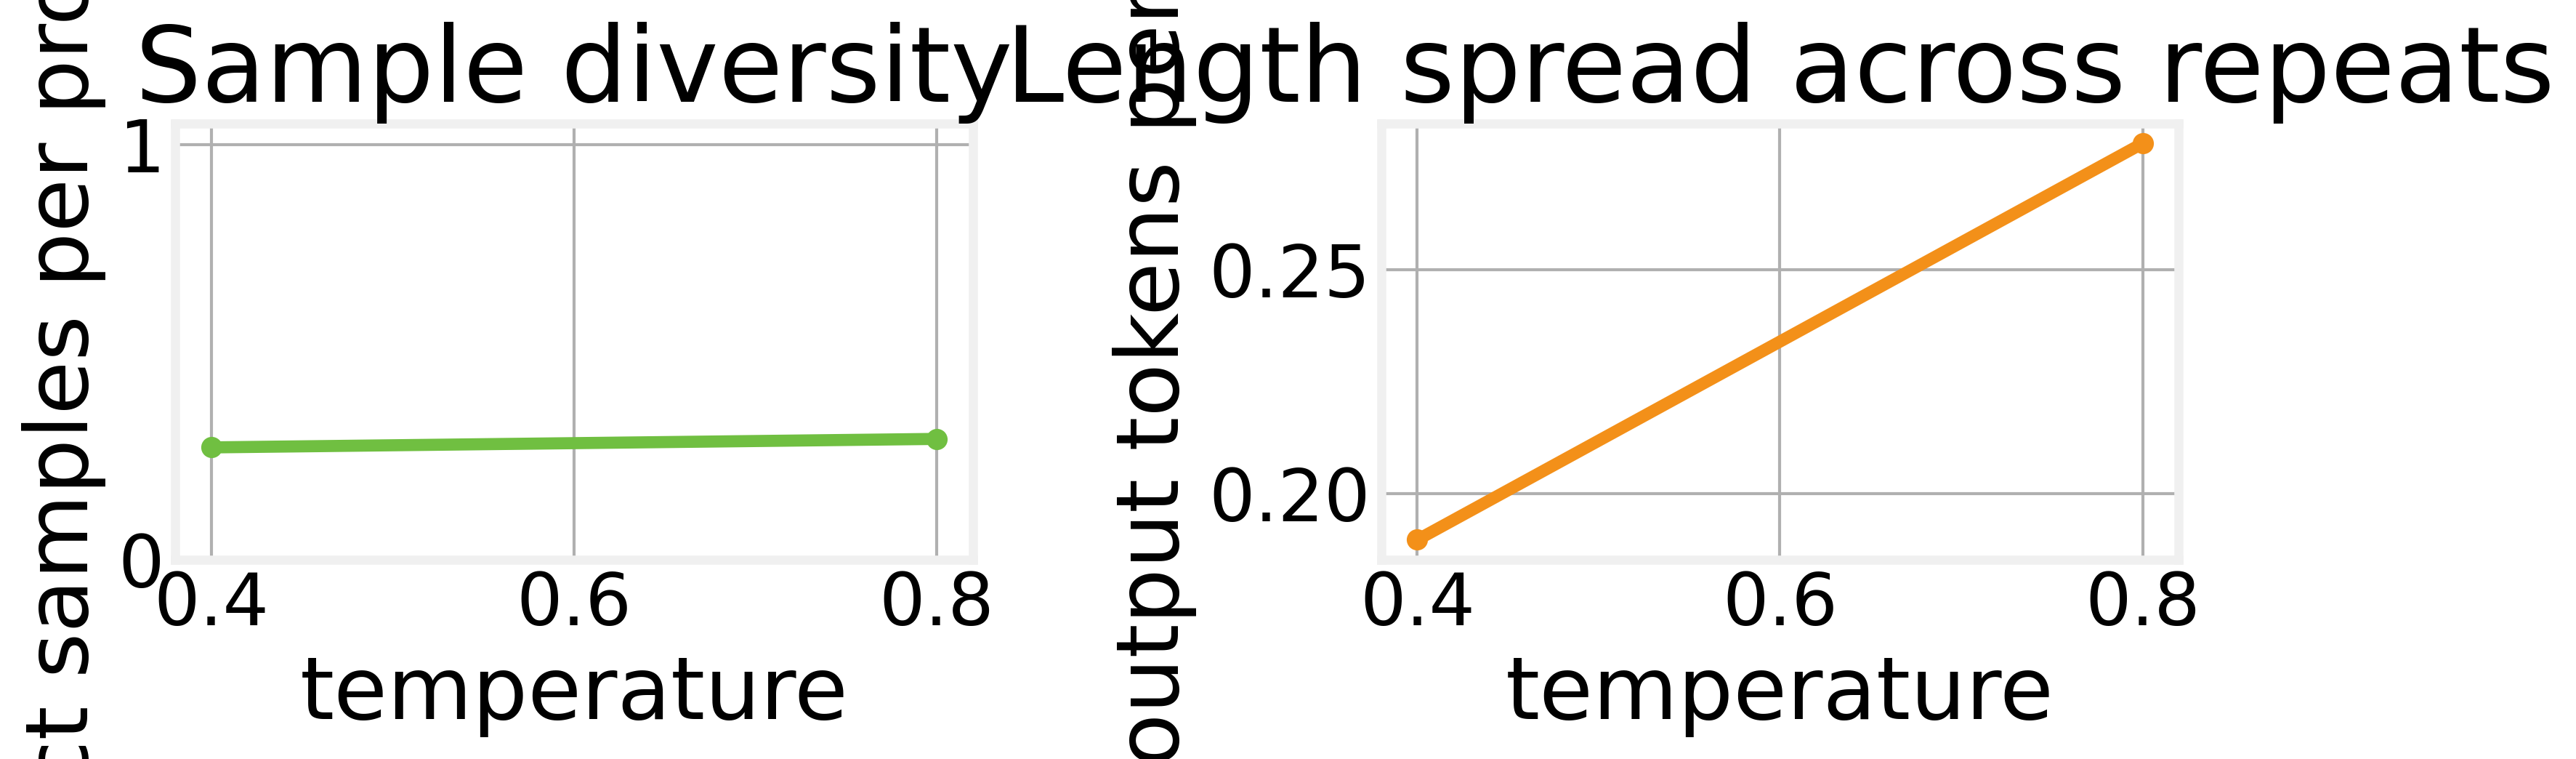

In [13]:
# Why repeat variation: this chart answers what temperature buys in output diversity.
rep = gen_df[gen_df.temperature > 0]
if N_SAMPLES > 1 and len(rep):
    g = rep.groupby(["temperature", "n_prompts", "prompt_idx"]).agg(
        uniq=("text", "nunique"), k=("text", "size"), tok_std=("out_tokens", "std"))
    g["uniq_ratio"] = g.uniq / g.k
    per_t = g.groupby(level="temperature").agg(
        uniq_ratio=("uniq_ratio", "mean"), tok_std=("tok_std", "mean"))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(per_t.index, per_t.uniq_ratio, "o-", color=colors[2])
    axes[0].set_ylim(0, 1.05)
    axes[0].set_xlabel("temperature")
    axes[0].set_ylabel(f"distinct samples per prompt / {N_SAMPLES}")
    axes[0].set_title("Sample diversity")

    axes[1].plot(per_t.index, per_t.tok_std, "o-", color=colors[3])
    axes[1].set_xlabel("temperature")
    axes[1].set_ylabel("std of output tokens per prompt")
    axes[1].set_title("Length spread across repeats")
    plt.tight_layout()
    plt.show()
else:
    print("repeat variation needs N_SAMPLES above 1 and a temperature above 0")

## Reading the numbers

Decode is bandwidth bound. The single-stream ceiling equals memory bandwidth divided by file size: on the Spark at 273 GB/s, a 4.7 GB Q4 file caps near 58 tok/s per stream. Aggregate output tok/s above that ceiling proves the batch amortizes weight reads across sequences, which is the whole point of continuous batching. Prompt tok/s is compute bound and should sit in the thousands on CUDA.

The temperature panels separate speed from workload. Output tok/s should hold roughly flat or climb across temperatures under vLLM, since repeats share the prefill and deepen the decode batch. Prompts per second falls above T=0, and the drop should track the sample multiplier. The length boxplot exposes the confound: longer outputs at higher temperatures shift tok/s for length reasons, not speed reasons, so compare speeds within one temperature.

The diversity panel guides sampling choices. A distinct-sample ratio near 1 means the temperature earns its repeats, a ratio near the single-copy floor means the samples waste compute. For classifier data generation, pick temperatures where the ratio saturates.

## Write results

Three artifacts per run. A summary JSON carries the config and every sweep row. A generations JSONL stores one record per sample: sequential `run_id`, temperature, prompt index, sample index, token count, and text. The leaderboard gains one row per config. The schema grew, so the file bumps to v2, and old rows stay untouched in the v1 file.

In [14]:
out_dir = Path(RESULTS_DIR)
out_dir.mkdir(exist_ok=True)
ts = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
stem = f"throughput__{model_path.stem}__{model_hash}__{ts}"

summary = {
    "run_id": ts,
    "model": {"file": model_path.name, "hash": model_hash,
              "size_gb": round(size_gb, 2), "gguf": meta, "tokenizer": TOKENIZER},
    "engine": {"name": ENGINE, "version": engine_version, "device": DEVICE,
               "max_new_tokens": MAX_NEW, "max_model_len": MAX_MODEL_LEN,
               "temperatures": TEMPERATURES, "n_samples": N_SAMPLES,
               "seed": SEED, "host": platform.node()},
    "dataset": {"name": "flowaicom/HaluEval", "split": "test",
                "unique_prompts_available": len(prompt_texts)},
    "sweep": rows,
}
with open(out_dir / f"{stem}.json", "w") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame(gen_log).to_json(out_dir / f"{stem}.generations.jsonl",
                              orient="records", lines=True)

lb = out_dir / "throughput_leaderboard_v2.csv"
lb_rows = [{
    "run_id": ts,
    "model": model_path.name,
    "hash": model_hash,
    "engine": ENGINE,
    "engine_version": engine_version,
    "device": DEVICE,
    **r,
} for r in rows]
pd.DataFrame(lb_rows).to_csv(lb, mode="a", header=not lb.exists(), index=False)
print("wrote", stem, "|", len(lb_rows), "leaderboard rows |", len(gen_log), "generations")

wrote throughput__Qwen2.5-7B-Instruct-Q4_K_M__3b3101d52a29__20260816-172542 | 6 leaderboard rows | 9900 generations


## Compare runs

Every model, engine, device, and temperature lands in one table. Sort by `output_tok_s` for decode speed, or filter on matching `n_prompts` and `temperature` to compare like with like. The chart below takes each setup's best decode number, so it compares peaks, not matched workloads.

In [15]:
board = pd.read_csv(out_dir / "throughput_leaderboard_v2.csv")
board.sort_values(["temperature", "n_prompts", "output_tok_s"],
                  ascending=[True, True, False])

,run_id,model,hash,engine,engine_version,device,temperature,n_prompts,n_samples,n_generations,wall_s,prompt_tokens,output_tokens,prompt_tok_s,output_tok_s,prompts_per_s
0,20260816-172542,Qwen2.5-7B-Instruct-Q4_K_M.gguf,3b3101d52a29,vllm,0.26.0,cuda,0.0,100,1,100,14.8,16236,449,1098,30,6.76
1,20260816-172542,Qwen2.5-7B-Instruct-Q4_K_M.gguf,3b3101d52a29,vllm,0.26.0,cuda,0.0,1000,1,1000,322.1,161108,4951,500,15,3.11
2,20260816-172542,Qwen2.5-7B-Instruct-Q4_K_M.gguf,3b3101d52a29,vllm,0.26.0,cuda,0.4,100,4,400,122.4,16236,1824,133,15,0.82
3,20260816-172542,Qwen2.5-7B-Instruct-Q4_K_M.gguf,3b3101d52a29,vllm,0.26.0,cuda,0.4,1000,4,4000,553.7,161108,20030,291,36,1.81
4,20260816-172542,Qwen2.5-7B-Instruct-Q4_K_M.gguf,3b3101d52a29,vllm,0.26.0,cuda,0.8,100,4,400,56.2,16236,1838,289,33,1.78
5,20260816-172542,Qwen2.5-7B-Instruct-Q4_K_M.gguf,3b3101d52a29,vllm,0.26.0,cuda,0.8,1000,4,4000,548.8,161108,20124,294,37,1.82


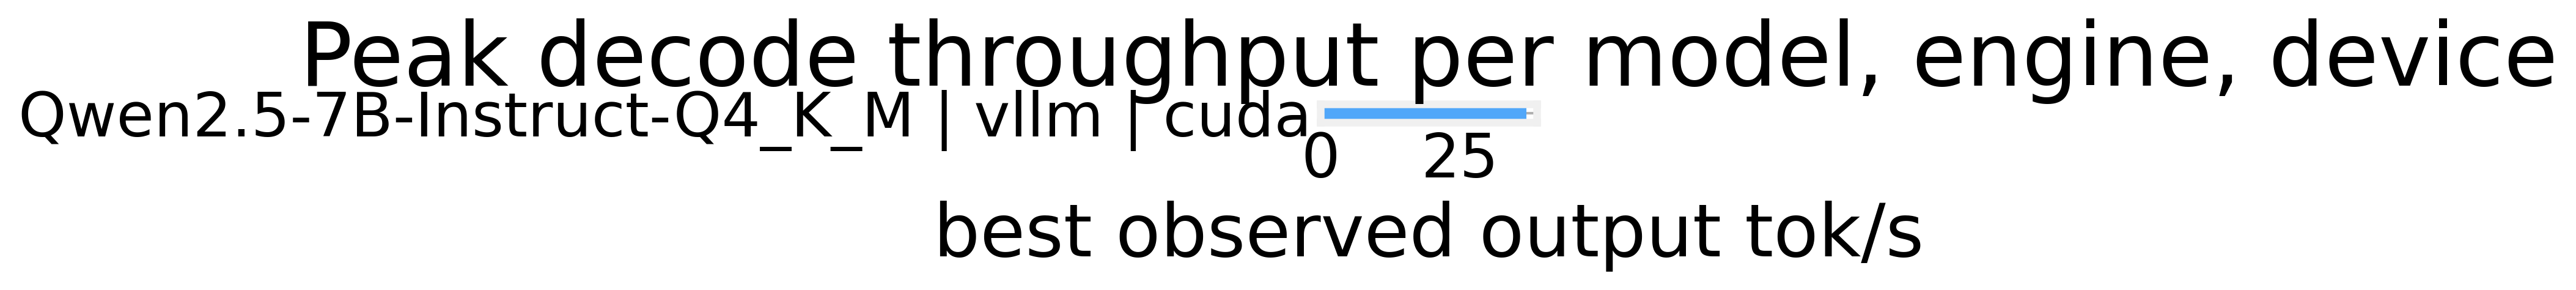

In [16]:
# Why best-row-per-setup: runs differ in counts and temps across machines, so this compares peaks only.
best = (board.sort_values("output_tok_s", ascending=False)
             .drop_duplicates(subset=["model", "engine", "device"])
             .sort_values("output_tok_s"))
labels = (best.model.str.replace(".gguf", "", regex=False)
          + " | " + best.engine + " | " + best.device)

fig, ax = plt.subplots(figsize=(9, 0.6 * len(best) + 1.5))
ax.barh(labels, best.output_tok_s, color=colors[0])
ax.set_xlabel("best observed output tok/s")
ax.set_title("Peak decode throughput per model, engine, device")
plt.tight_layout()
plt.show()

Swap the model trio and rerun top to bottom. The leaderboard accumulates. The generations JSONL doubles as raw material for the model-output classifier: prompt index, sample index, temperature, and text per row, keyed by model hash.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>